In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

正在读取数据...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


正在统计细胞数...


/tmp/ipykernel_3383770/3433654023.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_count_df = all_obs.groupby(['species', 'tissue', 'cell_type_level2']).size().reset_index(name='cell_count')
/tmp/ipykernel_3383770/3433654023.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_total_count = cell_count_df.groupby('cell_type_level2')['cell_count'].sum().reset_index(name='total_count')


正在自动生成排序...
✅ 只显示细胞数最多的前15种细胞类型：['CD4 T cell', 'Smooth muscle cell', 'Fibroblast', 'Homeostatic/Resident macrophage', 'B cell', 'Neutrophil', 'CD8 T cell', 'Natural killer cell', 'Arterial endothelial cell', 'Erythrocyte/Erythroid', 'Classical monocyte', 'Pericyte', 'Inflammatory macrophage', 'Fibromyocyte', 'Foamy macrophage']
✅ 物种-部位组合：[('Human', 'Unknown'), ('Human', 'Carotid Artery'), ('Human', 'Coronary Artery'), ('Human', 'Abdominal Aorta'), ('Human', 'Ascending Aorta'), ('Human', 'Aorta'), ('Human', 'Femoral Artery'), ('Human', 'Adventitia'), ('Human', 'Aorta and Brachiocephalic Artery'), ('Human', 'Aorta and Carotid Artery'), ('Human', 'Aortic root and Ascending Aorta'), ('Human', 'Ascending Aorta, Brachiocephalic Artery and Thoracic Aorta'), ('Mouse', 'Abdominal Aorta'), ('Mouse', 'Aorta'), ('Mouse', 'Aorta and Carotid Artery'), ('Mouse', 'Ascending Aorta, Brachiocephalic Artery and Thoracic Aorta'), ('Mouse', 'Aortic root and Ascending Aorta'), ('Mouse', 'Carotid Artery'), ('

/tmp/ipykernel_3383770/3433654023.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


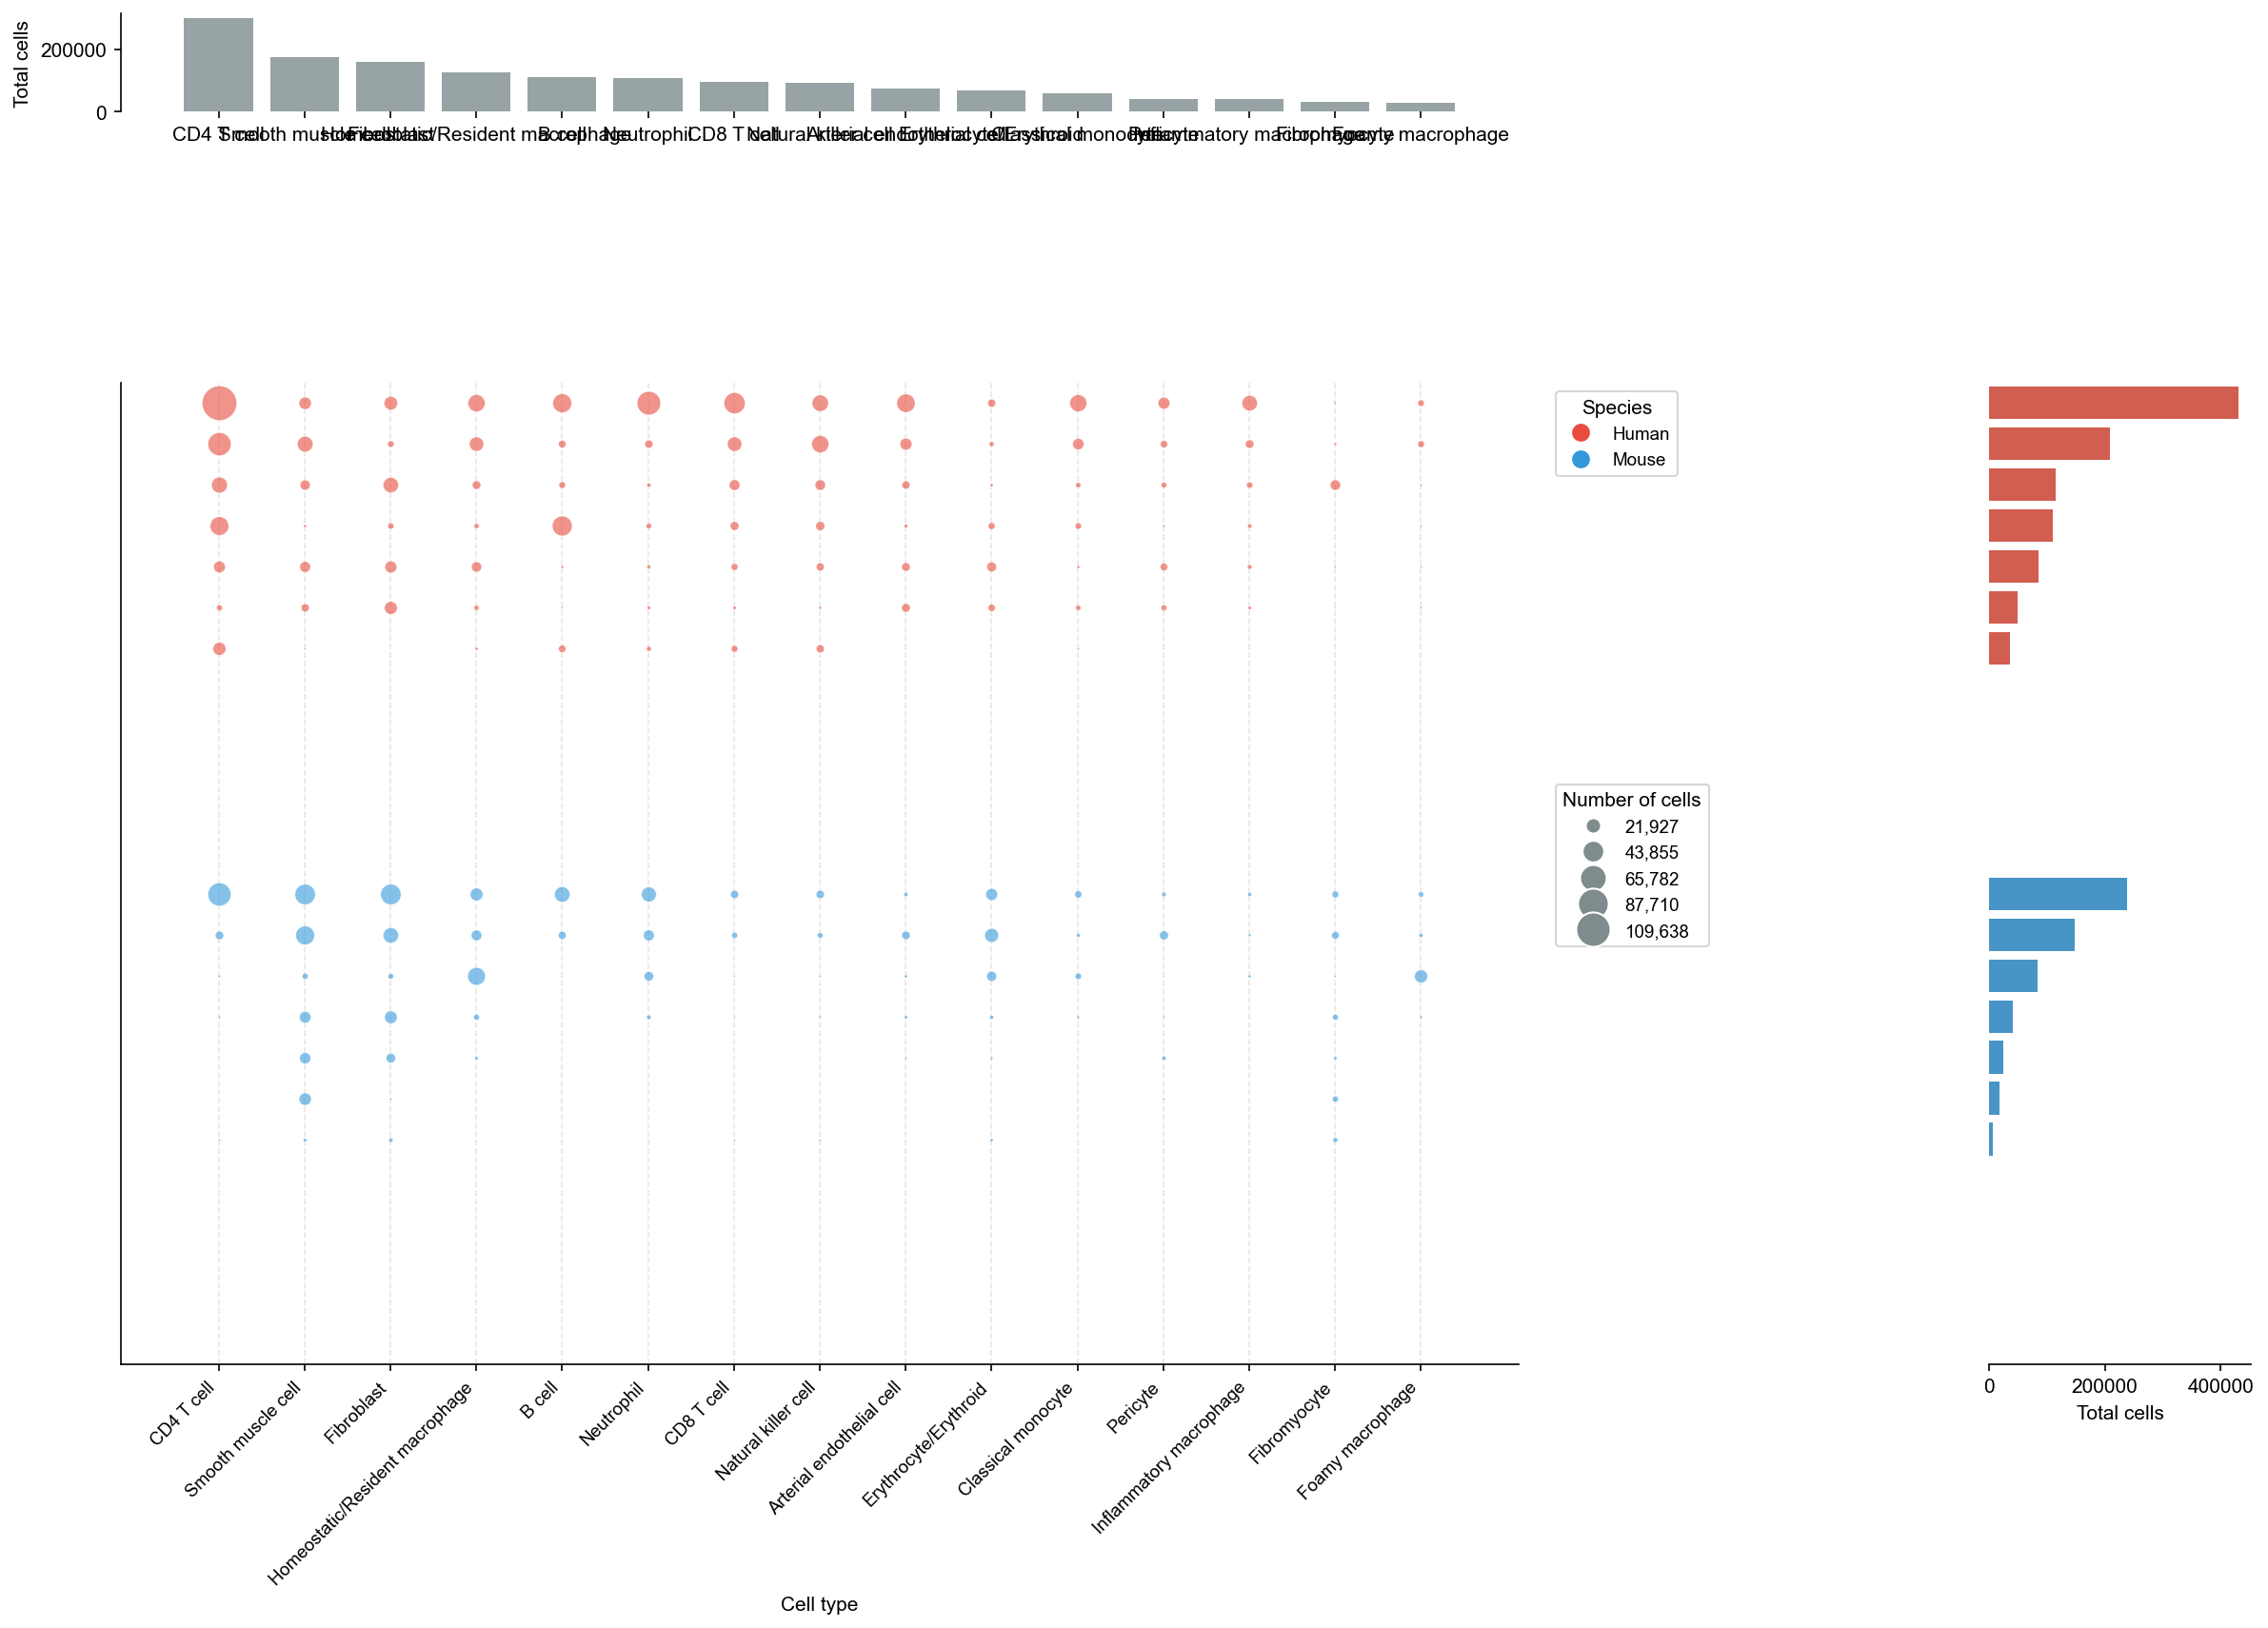

✅ 绘图完成！已修复气泡重叠和右侧条形图问题。


In [ ]:
# ==========================================
# 1. 读取数据、添加物种列、合并obs
# ==========================================
print("正在读取数据...")
adata_human = sc.read('/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad')
adata_human.obs['species'] = 'Human'
adata_mouse = sc.read('/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad')
adata_mouse.obs['species'] = 'Mouse'
all_obs = pd.concat([adata_human.obs, adata_mouse.obs], axis=0, ignore_index=True)

# ==========================================
# 2. 统计细胞数
# ==========================================
print("正在统计细胞数...")
cell_count_df = all_obs.groupby(['species', 'tissue', 'cell_type_level2']).size().reset_index(name='cell_count')
site_total_count = cell_count_df.groupby(['species', 'tissue'])['cell_count'].sum().reset_index(name='total_count')
celltype_total_count = cell_count_df.groupby('cell_type_level2')['cell_count'].sum().reset_index(name='total_count')

# ==========================================
# 3. 自动生成顺序（优化：只保留前15种细胞类型，防止太挤！）
# ==========================================
print("正在自动生成排序...")
# 3.1 细胞类型：只保留细胞数最多的前15种
top_n_celltypes = 15
celltype_order = celltype_total_count.sort_values('total_count', ascending=False).head(top_n_celltypes)['cell_type_level2'].tolist()
print(f"✅ 只显示细胞数最多的前{top_n_celltypes}种细胞类型：{celltype_order}")

# 3.2 物种-部位顺序
site_total_count_sorted = site_total_count.sort_values(by=['species', 'total_count'], ascending=[True, False])
site_order = list(zip(site_total_count_sorted['species'], site_total_count_sorted['tissue']))
print(f"✅ 物种-部位组合：{site_order}")

# ==========================================
# 4. 配置
# ==========================================
species_colors = {'Human': '#e74c3c', 'Mouse': '#3498db'}
bar_color = '#95a5a6'

# ==========================================
# 5. 绘制组合图（大幅优化！）
# ==========================================
print("\n正在绘图...")
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.dpi'] = 150

# 【优化1】大幅增加图的高度，给y轴更多空间
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, 
              height_ratios=[1, 10, 0.5],  # 增加中间气泡图的高度比例
              width_ratios=[8, 0.3, 1.5])

# --------------------------
# 1. 顶部：细胞类型总计数柱状图
# --------------------------
ax_top = fig.add_subplot(gs[0, 0])
# 只画前15种细胞类型
plot_data = celltype_total_count[celltype_total_count['cell_type_level2'].isin(celltype_order)]
sns.barplot(data=plot_data, x='cell_type_level2', y='total_count', 
            order=celltype_order, color=bar_color, ax=ax_top)
ax_top.set_xlabel('')
ax_top.set_ylabel('Total cells')
ax_top.set_xticks([])
ax_top.spines[['right', 'top', 'bottom']].set_visible(False)

# --------------------------
# 2. 中间：核心气泡图（大幅缩小气泡！）
# --------------------------
ax_bubble = fig.add_subplot(gs[1, 0], sharex=ax_top)
y_labels = [f'{s}\n{t}' for s, t in site_order]
y_pos = np.arange(len(site_order))

# 【优化2】大幅缩小气泡尺寸！从2000改成300
max_count = cell_count_df['cell_count'].max()
scale_factor = 300  

for y, (species, tissue) in enumerate(site_order):
    subset = cell_count_df[(cell_count_df['species']==species) & (cell_count_df['tissue']==tissue)]
    current_color = species_colors[species]
    
    for _, row in subset.iterrows():
        ct = row['cell_type_level2']
        # 只画前15种细胞类型
        if ct in celltype_order:
            x = celltype_order.index(ct)
            size = (row['cell_count'] / max_count) * scale_factor
            # 【优化3】增加边缘线，提高透明度，让重叠部分也能看清
            ax_bubble.scatter(x, y, s=size, color=current_color, alpha=0.6, 
                              edgecolor='white', linewidth=0.3, zorder=3)

ax_bubble.set_yticks(y_pos)
ax_bubble.set_yticklabels(y_labels, fontsize=10)
ax_bubble.set_ylim(-0.5, len(site_order)-0.5)
ax_bubble.set_xticks(np.arange(len(celltype_order)))
ax_bubble.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=9)
ax_bubble.set_xlabel('Cell type')
ax_bubble.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax_bubble.spines[['right', 'top']].set_visible(False)

# --------------------------
# 3. 右侧：部位总细胞数条形图（【关键修复】每个组合一个柱子！）
# --------------------------
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_bubble)
# 按site_order排序
site_total_count['site_label'] = site_total_count['species'] + '\n' + site_total_count['tissue']
site_total_count = site_total_count.set_index('site_label').reindex(y_labels).reset_index()

# 【关键修复】去掉hue，直接用palette传每个柱子的颜色
site_total_count['bar_color'] = site_total_count['species'].map(species_colors)
sns.barplot(
    data=site_total_count, 
    y='site_label', 
    x='total_count', 
    palette=site_total_count['bar_color'].tolist(),  # 每个柱子单独指定颜色
    ax=ax_right, 
    orient='h',
    dodge=False
)
ax_right.set_xlabel('Total cells')
ax_right.set_ylabel('')
ax_right.set_yticks([])
ax_right.spines[['right', 'top', 'left']].set_visible(False)

# --------------------------
# 4. 双图例
# --------------------------
species_legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=species_colors['Human'], markersize=10, label='Human'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=species_colors['Mouse'], markersize=10, label='Mouse')
]

# 动态生成图例大小
legend_sizes = [int(max_count * 0.2), int(max_count * 0.4), int(max_count * 0.6), int(max_count * 0.8), int(max_count)]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#7f8c8d', 
           markersize=np.sqrt((s / max_count) * scale_factor), label=f'{s:,}') 
    for s in legend_sizes
]

legend1 = ax_bubble.legend(handles=species_legend_elements, title='Species', 
                           bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax_bubble.add_artist(legend1)
legend2 = ax_bubble.legend(handles=size_legend_elements, title='Number of cells', 
                           bbox_to_anchor=(1.02, 0.6), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
print("✅ 绘图完成！已修复气泡重叠和右侧条形图问题。")

读取数据中...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/tmp/ipykernel_3383770/319555754.py:71: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_obs = pd.concat([human_obs, mouse_obs], axis=0)
/tmp/ipykernel_3383770/319555754.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass

Human cells: 161068
Mouse cells: 386027
Total cells: 547095

Human tissue counts:
tissue
Abdominal Aorta    111061
Aorta               50007
Ascending Aorta         0
Carotid Artery          0
Coronary Artery         0
Femoral Artery          0
Unknown                 0
Name: count, dtype: int64

Mouse tissue counts:
tissue
Abdominal Aorta                                               238039
Aorta                                                         147988
Adventitia                                                         0
Aorta and Brachiocephalic Artery                                   0
Aorta and Carotid Artery                                           0
Aortic root and Ascending Aorta                                    0
Ascending Aorta, Brachiocephalic Artery and Thoracic Aorta         0
Carotid Artery                                                     0
Name: count, dtype: int64

统计中...


/tmp/ipykernel_3383770/319555754.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df.groupby('cell_type_level2')['cell_count']



展示的 cell types:
['Smooth muscle cell', 'Fibroblast', 'B cell', 'Pericyte', 'Mast cell', 'Neutrophil', 'CD4 T cell', 'Erythrocyte/Erythroid', 'Homeostatic/Resident macrophage', 'Natural killer cell', 'CD8 T cell', 'Arterial endothelial cell']
开始绘图...


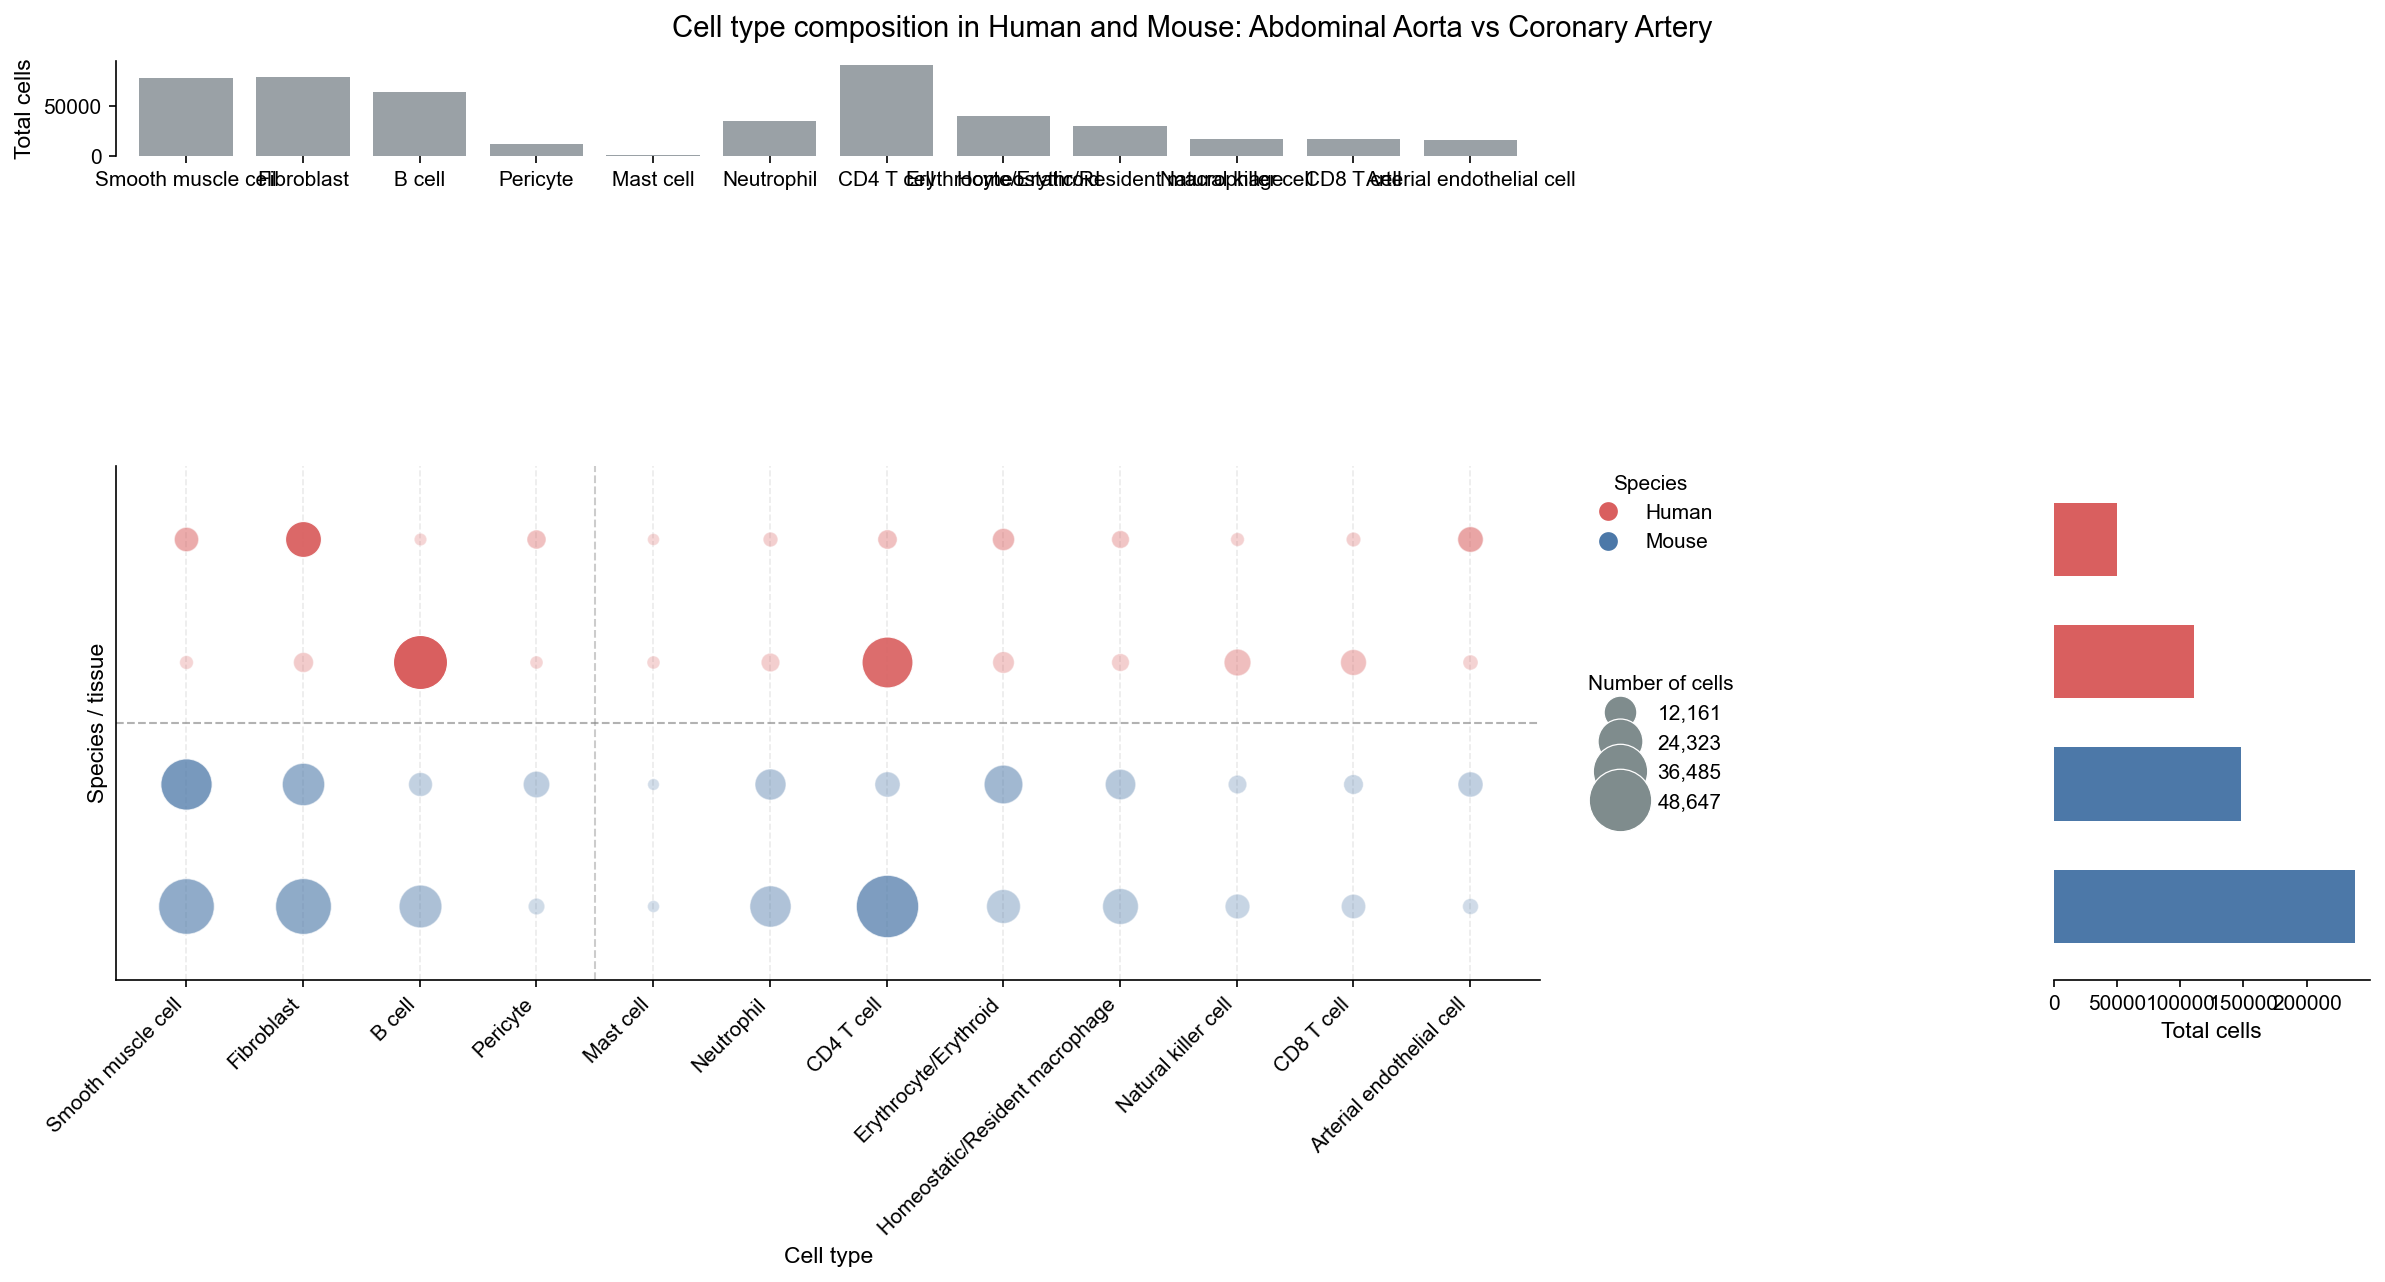

绘图完成。


In [17]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# =========================================================
# 0. 参数设置
# =========================================================
human_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad'
mouse_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad'

# 你要拆开的两个部位
target_tissues = ['Aorta', 'Abdominal Aorta']

# 展示的主要细胞类型数
top_n_celltypes = 12

# 优先展示的动脉相关细胞类型
preferred_order = [
    'Endothelial cell',
    'Smooth muscle cell',
    'Fibroblast',
    'Macrophage',
    'Monocyte',
    'T cell',
    'B cell',
    'Pericyte',
    'Mast cell',
    'Dendritic cell',
    'Neutrophil',
    'NK cell'
]

species_colors = {
    'Human': '#d95f5f',
    'Mouse': '#4c78a8'
}

min_bubble = 30
max_bubble = 900

# =========================================================
# 1. 读取数据
# =========================================================
print("读取数据中...")
adata_human = sc.read(human_path)
adata_mouse = sc.read(mouse_path)

adata_human.obs = adata_human.obs.copy()
adata_mouse.obs = adata_mouse.obs.copy()

adata_human.obs['species'] = 'Human'
adata_mouse.obs['species'] = 'Mouse'

required_cols = ['species', 'tissue', 'cell_type_level2']
for col in required_cols:
    if col not in adata_human.obs.columns:
        raise ValueError(f'Human 数据缺少列: {col}')
    if col not in adata_mouse.obs.columns:
        raise ValueError(f'Mouse 数据缺少列: {col}')

human_obs = adata_human.obs.copy()
mouse_obs = adata_mouse.obs.copy()

# 筛选指定部位
human_obs = human_obs[human_obs['tissue'].isin(target_tissues)].copy()
mouse_obs = mouse_obs[mouse_obs['tissue'].isin(target_tissues)].copy()

all_obs = pd.concat([human_obs, mouse_obs], axis=0)

print("Human cells:", human_obs.shape[0])
print("Mouse cells:", mouse_obs.shape[0])
print("Total cells:", all_obs.shape[0])

print("\nHuman tissue counts:")
print(human_obs['tissue'].value_counts())

print("\nMouse tissue counts:")
print(mouse_obs['tissue'].value_counts())

# =========================================================
# 2. 统计 count 和 proportion
#    每个 (species, tissue, celltype) 的细胞数
# =========================================================
print("\n统计中...")

count_df = (
    all_obs
    .groupby(['species', 'tissue', 'cell_type_level2'])
    .size()
    .reset_index(name='cell_count')
)

# 每个 (species, tissue) 的总细胞数
site_total_df = (
    all_obs
    .groupby(['species', 'tissue'])
    .size()
    .reset_index(name='site_total')
)

count_df = count_df.merge(site_total_df, on=['species', 'tissue'], how='left')
count_df['proportion'] = count_df['cell_count'] / count_df['site_total']

# =========================================================
# 3. 选择展示的细胞类型
#    在目标部位总体里选主要 cell types
# =========================================================
celltype_total = (
    count_df.groupby('cell_type_level2')['cell_count']
    .sum()
    .sort_values(ascending=False)
)

available_celltypes = celltype_total.index.tolist()

selected_celltypes = [ct for ct in preferred_order if ct in available_celltypes]

if len(selected_celltypes) < top_n_celltypes:
    for ct in available_celltypes:
        if ct not in selected_celltypes:
            selected_celltypes.append(ct)
        if len(selected_celltypes) >= top_n_celltypes:
            break

print("\n展示的 cell types:")
print(selected_celltypes)

plot_df = count_df[count_df['cell_type_level2'].isin(selected_celltypes)].copy()

# =========================================================
# 4. 构建完整组合，缺失补0
# =========================================================
species_order = ['Human', 'Mouse']
tissue_order = ['Aorta', 'Abdominal Aorta']

site_order = [
    ('Human', 'Aorta'),
    ('Human', 'Abdominal Aorta'),
    ('Mouse', 'Aorta'),
    ('Mouse', 'Abdominal Aorta')
]

full_index = pd.MultiIndex.from_product(
    [species_order, tissue_order, selected_celltypes],
    names=['species', 'tissue', 'cell_type_level2']
)

plot_df = (
    plot_df
    .set_index(['species', 'tissue', 'cell_type_level2'])
    .reindex(full_index)
    .reset_index()
)

plot_df = plot_df.merge(site_total_df, on=['species', 'tissue'], how='left', suffixes=('', '_y'))

plot_df['cell_count'] = plot_df['cell_count'].fillna(0)
plot_df['site_total'] = plot_df['site_total'].fillna(plot_df['site_total_y'])
plot_df = plot_df.drop(columns=[c for c in plot_df.columns if c.endswith('_y')])
plot_df['site_total'] = plot_df['site_total'].fillna(0)
plot_df['proportion'] = plot_df['proportion'].fillna(0)

# 只保留真的存在的 site
existing_sites = (
    site_total_df
    .assign(site_label=lambda x: x['species'] + ' | ' + x['tissue'])
)

existing_site_tuples = list(zip(site_total_df['species'], site_total_df['tissue']))
site_order = [x for x in site_order if x in existing_site_tuples]

if len(site_order) == 0:
    raise ValueError("筛选后没有细胞，请检查 tissue 名称是否正确。")

plot_df = plot_df[
    plot_df.apply(lambda r: (r['species'], r['tissue']) in site_order, axis=1)
].copy()

# =========================================================
# 5. 排序
# =========================================================
plot_df['species'] = pd.Categorical(plot_df['species'], categories=species_order, ordered=True)
plot_df['tissue'] = pd.Categorical(plot_df['tissue'], categories=tissue_order, ordered=True)
plot_df['cell_type_level2'] = pd.Categorical(plot_df['cell_type_level2'], categories=selected_celltypes, ordered=True)

plot_df = plot_df.sort_values(['species', 'tissue', 'cell_type_level2'])

# y轴标签
y_labels = [f'{s}\n{t}' for s, t in site_order]
y_positions = {site: i for i, site in enumerate(reversed(site_order))}
# reversed 后最上面是 Human Abdominal Aorta，最下面是 Mouse Coronary Artery 更直观

# 实际位置映射
site_to_y = {}
for idx, site in enumerate(site_order):
    site_to_y[site] = len(site_order) - 1 - idx

# =========================================================
# 6. 气泡大小与透明度
#    大小 = cell_count
#    透明度 = proportion
# =========================================================
max_count = max(plot_df['cell_count'].max(), 1)
max_prop = max(plot_df['proportion'].max(), 1e-9)

def size_map(x, min_size=min_bubble, max_size=max_bubble, max_count=max_count):
    return min_size + (x / max_count) * (max_size - min_size)

def alpha_map(p, max_prop=max_prop):
    return 0.25 + 0.75 * (p / max_prop)

plot_df['bubble_size'] = plot_df['cell_count'].apply(size_map)
plot_df['alpha'] = plot_df['proportion'].apply(alpha_map)

# =========================================================
# 7. 绘图
# =========================================================
print("开始绘图...")
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

fig = plt.figure(figsize=(16, 9))
gs = GridSpec(
    3, 3, figure=fig,
    height_ratios=[1.3, 7, 0.35],
    width_ratios=[9, 0.45, 2]
)

# -----------------------------
# 顶部：每个 cell type 的总细胞数
# -----------------------------
ax_top = fig.add_subplot(gs[0, 0])

top_bar_df = (
    plot_df.groupby('cell_type_level2', observed=False)['cell_count']
    .sum()
    .reindex(selected_celltypes)
    .reset_index()
)

ax_top.bar(
    x=np.arange(len(selected_celltypes)),
    height=top_bar_df['cell_count'],
    color='#9aa1a6',
    width=0.8
)

ax_top.set_ylabel('Total cells', fontsize=11)
ax_top.set_xticks([])
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.spines['bottom'].set_visible(False)

# -----------------------------
# 中间：气泡图
# 行 = species+tissue
# 列 = celltype
# 大小 = cell_count
# 透明度 = proportion
# -----------------------------
ax_bubble = fig.add_subplot(gs[1, 0], sharex=ax_top)

x_positions = {ct: i for i, ct in enumerate(selected_celltypes)}

for _, row in plot_df.iterrows():
    site = (row['species'], row['tissue'])
    if site not in site_to_y:
        continue

    x = x_positions[row['cell_type_level2']]
    y = site_to_y[site]
    color = species_colors[row['species']]

    ax_bubble.scatter(
        x, y,
        s=row['bubble_size'],
        color=color,
        alpha=row['alpha'],
        edgecolor='white',
        linewidth=0.6,
        zorder=3
    )

ax_bubble.set_xlim(-0.6, len(selected_celltypes) - 0.4)
ax_bubble.set_ylim(-0.6, len(site_order) - 0.4)
ax_bubble.set_xticks(np.arange(len(selected_celltypes)))
ax_bubble.set_xticklabels(selected_celltypes, rotation=45, ha='right', fontsize=10)
ax_bubble.set_yticks(np.arange(len(site_order)))
ax_bubble.set_yticklabels(list(reversed(y_labels)), fontsize=11)
ax_bubble.set_xlabel('Cell type', fontsize=11)
ax_bubble.set_ylabel('Species / tissue', fontsize=11)

ax_bubble.grid(axis='both', linestyle='--', alpha=0.25, zorder=0)
ax_bubble.spines['top'].set_visible(False)
ax_bubble.spines['right'].set_visible(False)

# human / mouse 分隔线
if len(site_order) == 4:
    ax_bubble.axhline(y=1.5, linestyle='--', color='grey', alpha=0.6, linewidth=1)

# 可选：血管壁细胞 vs 免疫细胞分组线（按你的 selected_celltypes 调整）
# 例如如果前4个是 vessel wall cells:
if len(selected_celltypes) > 4:
    ax_bubble.axvline(x=3.5, linestyle='--', color='grey', alpha=0.4, linewidth=1)

# -----------------------------
# 右侧：每个 site 总细胞数
# -----------------------------
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_bubble)

site_total_plot = (
    site_total_df
    .assign(site_tuple=lambda x: list(zip(x['species'], x['tissue'])))
)

site_total_plot['site_tuple'] = list(zip(site_total_plot['species'], site_total_plot['tissue']))
site_total_plot = site_total_plot[site_total_plot['site_tuple'].isin(site_order)].copy()

site_total_plot['y'] = site_total_plot['site_tuple'].map(site_to_y)
site_total_plot = site_total_plot.sort_values('y')

ax_right.barh(
    y=site_total_plot['y'],
    width=site_total_plot['site_total'],
    color=[species_colors[s] for s in site_total_plot['species']],
    height=0.6
)

ax_right.set_xlabel('Total cells', fontsize=11)
ax_right.set_yticks([])
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)

# -----------------------------
# 图例1：species
# -----------------------------
species_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=species_colors['Human'], markersize=10, label='Human'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=species_colors['Mouse'], markersize=10, label='Mouse')
]

legend1 = ax_bubble.legend(
    handles=species_handles,
    title='Species',
    bbox_to_anchor=(1.02, 1.02),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)
ax_bubble.add_artist(legend1)

# -----------------------------
# 图例2：bubble size
# -----------------------------
size_breaks = sorted(set([
    int(max_count * 0.25),
    int(max_count * 0.5),
    int(max_count * 0.75),
    int(max_count)
]))
size_breaks = [s for s in size_breaks if s > 0]

size_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#7f8c8d',
        markeredgecolor='white',
        markeredgewidth=0.6,
        markersize=np.sqrt(size_map(s)),
        label=f'{s:,}'
    )
    for s in size_breaks
]

legend2 = ax_bubble.legend(
    handles=size_handles,
    title='Number of cells',
    bbox_to_anchor=(1.02, 0.63),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

# -----------------------------
# 标题
# -----------------------------
fig.suptitle(
    'Cell type composition in Human and Mouse: Abdominal Aorta vs Coronary Artery',
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.show()

print("绘图完成。")

### new

In [2]:
adata_human =sc.read_h5ad('/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad')

In [3]:
adata_human.obs["Plaque_type"] = "Unknown"

In [4]:
# unstable
mask = adata_human.obs['dataset'].isin(['2-ZDZJ', 'AAA-MAX', 'AAA-P','AAA-PRO','AIOD-3LIB','AS-CFA','AS-FA','CFA-BWD','CFA-PLA',
                                        'ISR-7-1','POP-ISR-A','POP-ISR2-B','TAA-A1-5-3LIB','TAA-B1-5-3LIB','TAD1-Z3-3LIB',
                                        'TAD2-Z1-3LIB','IAISR'])##
# 批量修改
adata_human.obs.loc[mask, 'Plaque_type'] = 'unstable'

In [5]:
adata_human.obs['Plaque_type'].value_counts()

Plaque_type
Unknown     885331
unstable    150757
Name: count, dtype: int64

In [6]:
# stable
mask = adata_human.obs['dataset'].isin(['AS-POP', 'CBT', 'IA-1-3LIB','ISR-7-2','ISR-8','ISR-9','SFA-8'])##'IAISR'
# 批量修改
adata_human.obs.loc[mask, 'Plaque_type'] = 'stable'

In [7]:
adata_human.obs['Plaque_type'].value_counts()

Plaque_type
Unknown     824838
unstable    150757
stable       60493
Name: count, dtype: int64

读取数据中...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


Human condition unique:
['AAA', 'AD', 'ATAA', 'Atherosclerosis', 'Atherosclerosis,ISR', 'CBT', 'Healthy', 'IAA', 'MF', 'TAA']
Mouse condition unique:
['AAA', 'AAD', 'Atherosclerosis', 'Atherosclerosis+Diabetes', 'Healthy', 'IMH', 'Vascular injury (neointima formation)']
Human cells: 460743
Mouse cells: 345494
Total cells: 806237

Human condition counts:
condition
Atherosclerosis    357506
Healthy            103237
Name: count, dtype: int64

Mouse condition counts:
condition
Atherosclerosis    279658
Healthy             65836
Name: count, dtype: int64

统计中...


/tmp/ipykernel_3383770/3735645325.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_obs
/tmp/ipykernel_3383770/3735645325.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df.groupby('cell_type_level2')['cell_count']



展示的 cell types:
['Smooth muscle cell', 'Fibroblast', 'B cell', 'Pericyte', 'Mast cell', 'Neutrophil', 'CD4 T cell', 'Homeostatic/Resident macrophage', 'Natural killer cell', 'CD8 T cell', 'Erythrocyte/Erythroid', 'Arterial endothelial cell']
开始绘图...


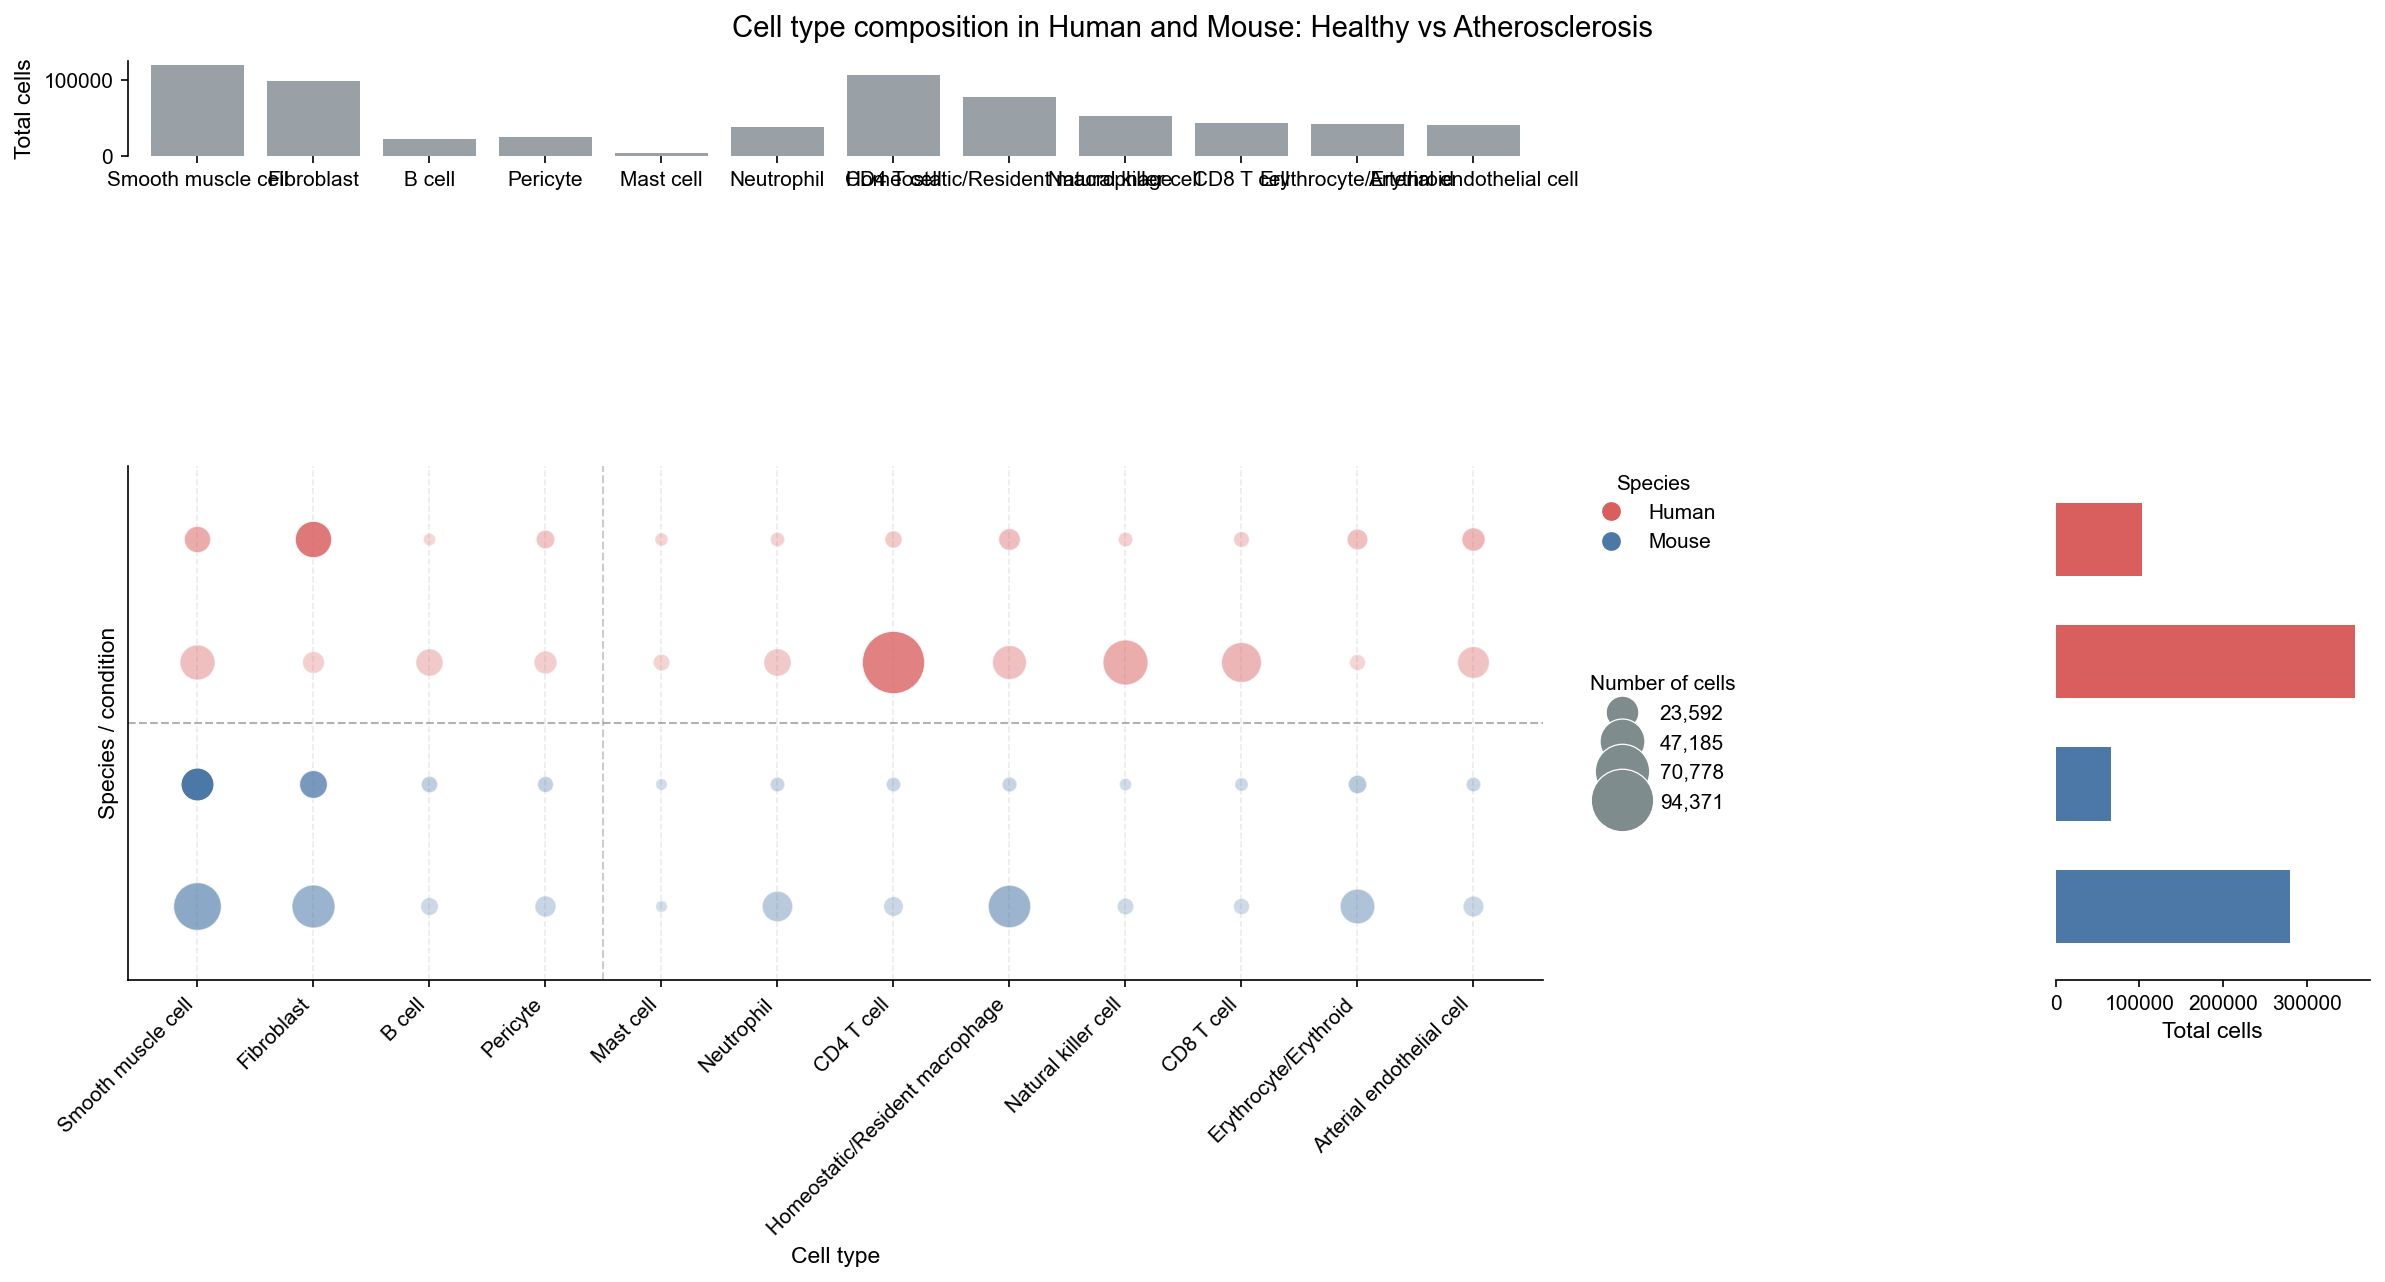

绘图完成。


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# =========================================================
# 0. 参数设置
# =========================================================
# human_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-human_withUMAP2.h5ad'
mouse_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_0121/Big-atlas-withlevel3-mouse_withUMAP2.h5ad'

target_conditions = ['Healthy', 'Atherosclerosis']

top_n_celltypes = 12

preferred_order = [
    'Endothelial cell',
    'Smooth muscle cell',
    'Fibroblast',
    'Macrophage',
    'Monocyte',
    'T cell',
    'B cell',
    'Pericyte',
    'Mast cell',
    'Dendritic cell',
    'Neutrophil',
    'NK cell'
]

species_colors = {
    'Human': '#d95f5f',
    'Mouse': '#4c78a8'
}

min_bubble = 30
max_bubble = 900

# =========================================================
# 1. 读取数据
# =========================================================
print("读取数据中...")
# adata_human = sc.read(human_path)
adata_mouse = sc.read(mouse_path)

adata_human.obs = adata_human.obs.copy()
adata_mouse.obs = adata_mouse.obs.copy()

adata_human.obs['species'] = 'Human'
adata_mouse.obs['species'] = 'Mouse'

# 人类用 symptoms，小鼠用 disease，统一到 condition
if 'symptoms' not in adata_human.obs.columns:
    raise ValueError("Human 数据缺少列: symptoms")

if 'disease' not in adata_mouse.obs.columns:
    raise ValueError("Mouse 数据缺少列: disease")

if 'cell_type_level2' not in adata_human.obs.columns:
    raise ValueError("Human 数据缺少列: cell_type_level2")

if 'cell_type_level2' not in adata_mouse.obs.columns:
    raise ValueError("Mouse 数据缺少列: cell_type_level2")

adata_human.obs['condition'] = adata_human.obs['symptoms'].astype(str)
adata_mouse.obs['condition'] = adata_mouse.obs['disease'].astype(str)

print("Human condition unique:")
print(sorted(adata_human.obs['condition'].unique()))
print("Mouse condition unique:")
print(sorted(adata_mouse.obs['condition'].unique()))

# 只保留目标 condition
human_obs = adata_human.obs[adata_human.obs['condition'].isin(target_conditions)].copy()
mouse_obs = adata_mouse.obs[adata_mouse.obs['condition'].isin(target_conditions)].copy()

all_obs = pd.concat([human_obs, mouse_obs], axis=0)

print("Human cells:", human_obs.shape[0])
print("Mouse cells:", mouse_obs.shape[0])
print("Total cells:", all_obs.shape[0])

print("\nHuman condition counts:")
print(human_obs['condition'].value_counts())

print("\nMouse condition counts:")
print(mouse_obs['condition'].value_counts())

# =========================================================
# 2. 统计 count 和 proportion
# =========================================================
print("\n统计中...")

count_df = (
    all_obs
    .groupby(['species', 'condition', 'cell_type_level2'])
    .size()
    .reset_index(name='cell_count')
)

group_total_df = (
    all_obs
    .groupby(['species', 'condition'])
    .size()
    .reset_index(name='group_total')
)

count_df = count_df.merge(group_total_df, on=['species', 'condition'], how='left')
count_df['proportion'] = count_df['cell_count'] / count_df['group_total']

# =========================================================
# 3. 选择展示的细胞类型
# =========================================================
celltype_total = (
    count_df.groupby('cell_type_level2')['cell_count']
    .sum()
    .sort_values(ascending=False)
)

available_celltypes = celltype_total.index.tolist()

selected_celltypes = [ct for ct in preferred_order if ct in available_celltypes]

if len(selected_celltypes) < top_n_celltypes:
    for ct in available_celltypes:
        if ct not in selected_celltypes:
            selected_celltypes.append(ct)
        if len(selected_celltypes) >= top_n_celltypes:
            break

print("\n展示的 cell types:")
print(selected_celltypes)

plot_df = count_df[count_df['cell_type_level2'].isin(selected_celltypes)].copy()

# =========================================================
# 4. 构建完整组合，缺失补0
# =========================================================
species_order = ['Human', 'Mouse']
condition_order = ['Healthy', 'Atherosclerosis']

group_order = [
    ('Human', 'Healthy'),
    ('Human', 'Atherosclerosis'),
    ('Mouse', 'Healthy'),
    ('Mouse', 'Atherosclerosis')
]

full_index = pd.MultiIndex.from_product(
    [species_order, condition_order, selected_celltypes],
    names=['species', 'condition', 'cell_type_level2']
)

plot_df = (
    plot_df
    .set_index(['species', 'condition', 'cell_type_level2'])
    .reindex(full_index)
    .reset_index()
)

plot_df = plot_df.merge(group_total_df, on=['species', 'condition'], how='left', suffixes=('', '_y'))

plot_df['cell_count'] = plot_df['cell_count'].fillna(0)
plot_df['group_total'] = plot_df['group_total'].fillna(plot_df['group_total_y'])
plot_df = plot_df.drop(columns=[c for c in plot_df.columns if c.endswith('_y')])
plot_df['group_total'] = plot_df['group_total'].fillna(0)
plot_df['proportion'] = plot_df['proportion'].fillna(0)

existing_group_tuples = list(zip(group_total_df['species'], group_total_df['condition']))
group_order = [x for x in group_order if x in existing_group_tuples]

if len(group_order) == 0:
    raise ValueError("筛选后没有细胞，请检查 condition 名称是否正确。")

plot_df = plot_df[
    plot_df.apply(lambda r: (r['species'], r['condition']) in group_order, axis=1)
].copy()

# =========================================================
# 5. 排序
# =========================================================
plot_df['species'] = pd.Categorical(plot_df['species'], categories=species_order, ordered=True)
plot_df['condition'] = pd.Categorical(plot_df['condition'], categories=condition_order, ordered=True)
plot_df['cell_type_level2'] = pd.Categorical(plot_df['cell_type_level2'], categories=selected_celltypes, ordered=True)

plot_df = plot_df.sort_values(['species', 'condition', 'cell_type_level2'])

y_labels = [f'{s}\n{cond}' for s, cond in group_order]

group_to_y = {}
for idx, group in enumerate(group_order):
    group_to_y[group] = len(group_order) - 1 - idx

# =========================================================
# 6. 气泡大小与透明度
# =========================================================
max_count = max(plot_df['cell_count'].max(), 1)
max_prop = max(plot_df['proportion'].max(), 1e-9)

def size_map(x, min_size=min_bubble, max_size=max_bubble, max_count=max_count):
    return min_size + (x / max_count) * (max_size - min_size)

def alpha_map(p, max_prop=max_prop):
    return 0.25 + 0.75 * (p / max_prop)

plot_df['bubble_size'] = plot_df['cell_count'].apply(size_map)
plot_df['alpha'] = plot_df['proportion'].apply(alpha_map)

# =========================================================
# 7. 绘图
# =========================================================
print("开始绘图...")
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

fig = plt.figure(figsize=(16, 9))
gs = GridSpec(
    3, 3, figure=fig,
    height_ratios=[1.3, 7, 0.35],
    width_ratios=[9, 0.45, 2]
)

# 顶部：每个 cell type 的总细胞数
ax_top = fig.add_subplot(gs[0, 0])

top_bar_df = (
    plot_df.groupby('cell_type_level2', observed=False)['cell_count']
    .sum()
    .reindex(selected_celltypes)
    .reset_index()
)

ax_top.bar(
    x=np.arange(len(selected_celltypes)),
    height=top_bar_df['cell_count'],
    color='#9aa1a6',
    width=0.8
)

ax_top.set_ylabel('Total cells', fontsize=11)
ax_top.set_xticks([])
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.spines['bottom'].set_visible(False)

# 中间：气泡图
ax_bubble = fig.add_subplot(gs[1, 0], sharex=ax_top)

x_positions = {ct: i for i, ct in enumerate(selected_celltypes)}

for _, row in plot_df.iterrows():
    group = (row['species'], row['condition'])
    if group not in group_to_y:
        continue

    x = x_positions[row['cell_type_level2']]
    y = group_to_y[group]
    color = species_colors[row['species']]

    ax_bubble.scatter(
        x, y,
        s=row['bubble_size'],
        color=color,
        alpha=row['alpha'],
        edgecolor='white',
        linewidth=0.6,
        zorder=3
    )

ax_bubble.set_xlim(-0.6, len(selected_celltypes) - 0.4)
ax_bubble.set_ylim(-0.6, len(group_order) - 0.4)
ax_bubble.set_xticks(np.arange(len(selected_celltypes)))
ax_bubble.set_xticklabels(selected_celltypes, rotation=45, ha='right', fontsize=10)
ax_bubble.set_yticks(np.arange(len(group_order)))
ax_bubble.set_yticklabels(list(reversed(y_labels)), fontsize=11)
ax_bubble.set_xlabel('Cell type', fontsize=11)
ax_bubble.set_ylabel('Species / condition', fontsize=11)

ax_bubble.grid(axis='both', linestyle='--', alpha=0.25, zorder=0)
ax_bubble.spines['top'].set_visible(False)
ax_bubble.spines['right'].set_visible(False)

if len(group_order) == 4:
    ax_bubble.axhline(y=1.5, linestyle='--', color='grey', alpha=0.6, linewidth=1)

if len(selected_celltypes) > 4:
    ax_bubble.axvline(x=3.5, linestyle='--', color='grey', alpha=0.4, linewidth=1)

# 右侧：每个 group 总细胞数
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_bubble)

group_total_plot = group_total_df.copy()
group_total_plot['group_tuple'] = list(zip(group_total_plot['species'], group_total_plot['condition']))
group_total_plot = group_total_plot[group_total_plot['group_tuple'].isin(group_order)].copy()
group_total_plot['y'] = group_total_plot['group_tuple'].map(group_to_y)
group_total_plot = group_total_plot.sort_values('y')

ax_right.barh(
    y=group_total_plot['y'],
    width=group_total_plot['group_total'],
    color=[species_colors[s] for s in group_total_plot['species']],
    height=0.6
)

ax_right.set_xlabel('Total cells', fontsize=11)
ax_right.set_yticks([])
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)

# 图例1：species
species_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=species_colors['Human'], markersize=10, label='Human'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=species_colors['Mouse'], markersize=10, label='Mouse')
]

legend1 = ax_bubble.legend(
    handles=species_handles,
    title='Species',
    bbox_to_anchor=(1.02, 1.02),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)
ax_bubble.add_artist(legend1)

# 图例2：bubble size
size_breaks = sorted(set([
    int(max_count * 0.25),
    int(max_count * 0.5),
    int(max_count * 0.75),
    int(max_count)
]))
size_breaks = [s for s in size_breaks if s > 0]

size_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#7f8c8d',
        markeredgecolor='white',
        markeredgewidth=0.6,
        markersize=np.sqrt(size_map(s)),
        label=f'{s:,}'
    )
    for s in size_breaks
]

legend2 = ax_bubble.legend(
    handles=size_handles,
    title='Number of cells',
    bbox_to_anchor=(1.02, 0.63),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

fig.suptitle(
    'Cell type composition in Human and Mouse: Healthy vs Atherosclerosis',
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.show()

print("绘图完成。")

#### add Plaque_type

In [5]:
human_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_260420/Big-atlas-getlevel3-human-matedata.h5ad'
mouse_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_260420/Mouse_level3/Big-atlas-withlevel3-mouse.h5ad'
print("读取数据中...")
adata_human= sc.read(human_path)
adata_mouse = sc.read(mouse_path)

读取数据中...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


Human symptoms:
condition
Atherosclerosis        430452
not stated             117138
Healthy                107092
Atherosclerosis,ISR     96864
TAA                     83893
AAA                     77992
ATAA                    38669
AD                      33066
IAA                     22944
MF                      16147
CBT                      8366
Name: count, dtype: int64

Human Plaque_type cleaned:
plaque_type_clean
unknown     800276
unstable    171841
stable       60506
Name: count, dtype: int64

Mouse symptoms:
condition
Atherosclerosis    268441
AAA                143261
Healthy             65202
IMH                 44659
AAD                 16837
atherosclerosis      1980
RA                   1656
Name: count, dtype: int64

Human plot groups:
condition_plot
Disease            925531
Plaque_Unstable    171841
Healthy            107092
Plaque_Stable       60506
Name: count, dtype: int64

Mouse plot groups:
condition_plot
Disease    476834
Healthy     65202
Name: count, dtype

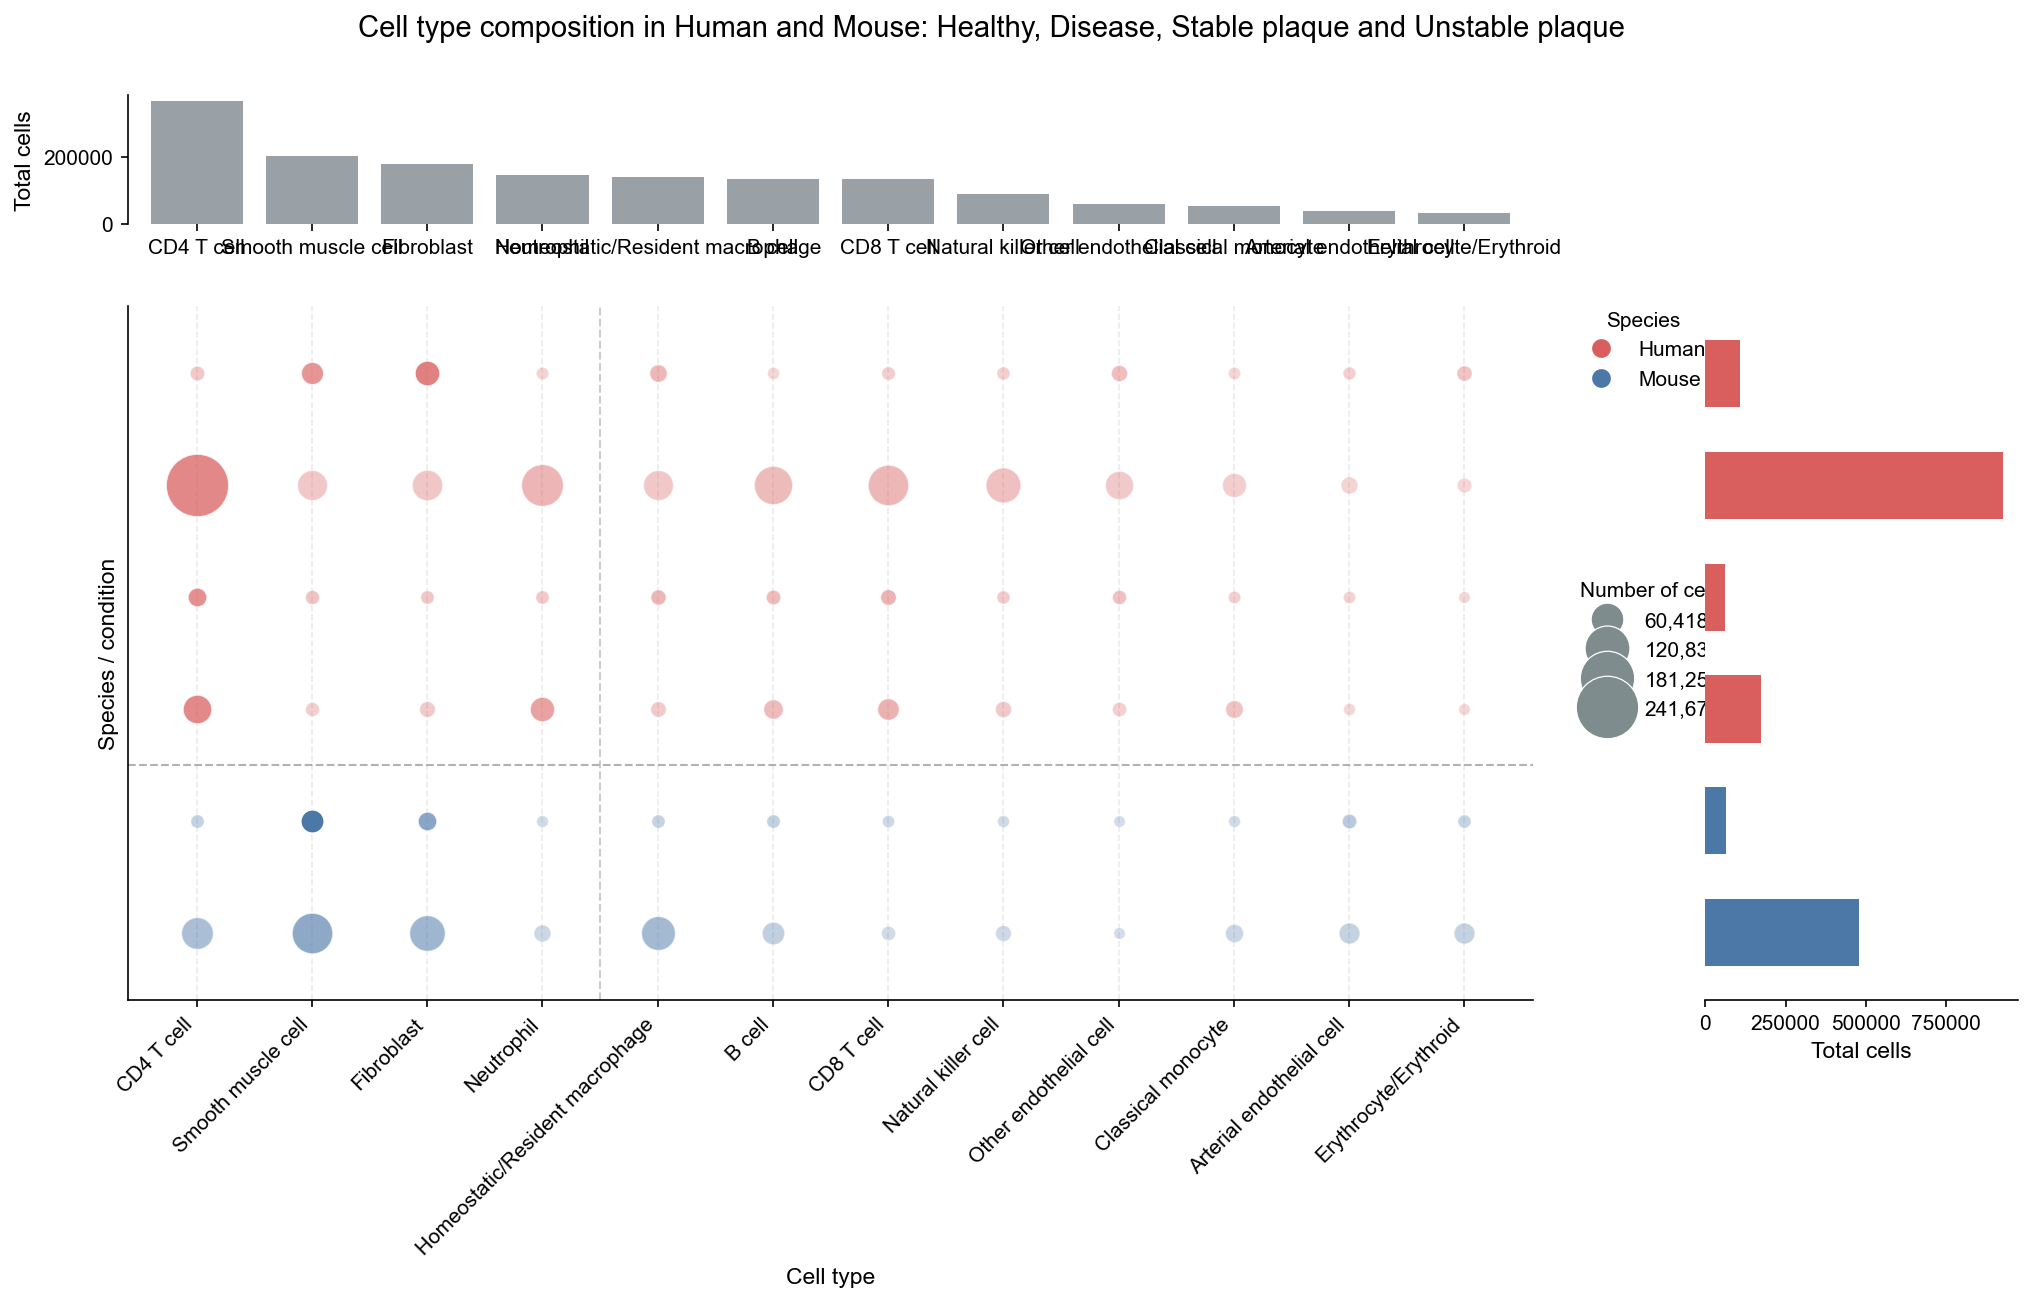

绘图完成。


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# =========================================================
# 0. 参数设置
# =========================================================

plaque_col = 'Plaque_type'
celltype_col = 'cell_type_level2'
condition_col = 'symptoms'

healthy_name = 'Healthy'
disease_name = 'Disease'

top_n_celltypes = 12

preferred_order = [
    'Endothelial cell', 'Smooth muscle cell', 'Fibroblast',
    'Macrophage', 'Monocyte', 'T cell', 'B cell',
    'Pericyte', 'Mast cell', 'Dendritic cell',
    'Neutrophil', 'NK cell'
]

species_colors = {
    'Human': '#d95f5f',
    'Mouse': '#4c78a8'
}

label_map = {
    'Healthy': 'Healthy',
    'Disease': 'Disease',
    'Plaque_Stable': 'Stable plaque',
    'Plaque_Unstable': 'Unstable plaque'
}

group_order = [
    ('Human', 'Healthy'),
    ('Human', 'Disease'),
    ('Human', 'Plaque_Stable'),
    ('Human', 'Plaque_Unstable'),
    ('Mouse', 'Healthy'),
    ('Mouse', 'Disease')
]

min_bubble = 30
max_bubble = 900

# =========================================================
# 1. 检查列
# =========================================================

required_human_cols = [condition_col, plaque_col, celltype_col]
required_mouse_cols = [condition_col, celltype_col]

for col in required_human_cols:
    if col not in adata_human.obs.columns:
        raise ValueError(f"Human 数据缺少列: {col}")

for col in required_mouse_cols:
    if col not in adata_mouse.obs.columns:
        raise ValueError(f"Mouse 数据缺少列: {col}")

# =========================================================
# 2. 整理 human / mouse obs
# =========================================================

human = adata_human.obs.copy()
mouse = adata_mouse.obs.copy()

human['species'] = 'Human'
mouse['species'] = 'Mouse'

human['condition'] = human[condition_col].astype(str).str.strip()
mouse['condition'] = mouse[condition_col].astype(str).str.strip()

# 如果小鼠里有 Atherosclerosis+Diabetes，也合并成 Atherosclerosis 后再进入 Disease
mouse['condition'] = mouse['condition'].replace({
    'Atherosclerosis+Diabetes': 'Atherosclerosis'
})

# 如果人类里也有 Atherosclerosis+Diabetes，同样合并
human['condition'] = human['condition'].replace({
    'Atherosclerosis+Diabetes': 'Atherosclerosis'
})

# 清洗 Plaque_type，兼容 stable plaque / stable_plaque / Stable 等写法
human['plaque_type_clean'] = (
    human[plaque_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('-', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

plaque_map = {
    'stable': 'Plaque_Stable',
    'stable_plaque': 'Plaque_Stable',
    'plaque_stable': 'Plaque_Stable',

    'unstable': 'Plaque_Unstable',
    'unstable_plaque': 'Plaque_Unstable',
    'plaque_unstable': 'Plaque_Unstable'
}

print("Human symptoms:")
print(human['condition'].value_counts(dropna=False))

print("\nHuman Plaque_type cleaned:")
print(human['plaque_type_clean'].value_counts(dropna=False).head(30))

print("\nMouse symptoms:")
print(mouse['condition'].value_counts(dropna=False))

# =========================================================
# 3. 构建绘图分组
# =========================================================

# Human Healthy
human_healthy = human[human['condition'].eq(healthy_name)].copy()
human_healthy['condition_plot'] = 'Healthy'

# Human Disease：所有非 Healthy 的疾病
human_disease = human[~human['condition'].eq(healthy_name)].copy()
human_disease['condition_plot'] = disease_name

# Human Stable / Unstable plaque：按 Plaque_type 分
human_plaque = human[human['plaque_type_clean'].isin(plaque_map)].copy()
human_plaque['condition_plot'] = human_plaque['plaque_type_clean'].map(plaque_map)

# Mouse Healthy / Disease：所有非 Healthy 合并为 Disease
mouse_plot = mouse.copy()
mouse_plot['condition_plot'] = np.where(
    mouse_plot['condition'].eq(healthy_name),
    'Healthy',
    disease_name
)

all_obs = pd.concat(
    [human_healthy, human_disease, human_plaque, mouse_plot],
    axis=0
)

print("\nHuman plot groups:")
print(
    all_obs[all_obs['species'].eq('Human')]
    ['condition_plot']
    .value_counts(dropna=False)
)

print("\nMouse plot groups:")
print(
    all_obs[all_obs['species'].eq('Mouse')]
    ['condition_plot']
    .value_counts(dropna=False)
)

if all_obs.empty:
    raise ValueError("筛选后没有细胞，请检查 symptoms 或 Plaque_type。")

# =========================================================
# 4. 统计 count 和 proportion
# =========================================================

count_df = (
    all_obs
    .groupby(['species', 'condition_plot', celltype_col])
    .size()
    .reset_index(name='cell_count')
)

group_total_df = (
    all_obs
    .groupby(['species', 'condition_plot'])
    .size()
    .reset_index(name='group_total')
)

count_df = count_df.merge(
    group_total_df,
    on=['species', 'condition_plot'],
    how='left'
)

count_df['proportion'] = count_df['cell_count'] / count_df['group_total']

# =========================================================
# 5. 选择展示的 cell types
# =========================================================

celltype_total = (
    count_df
    .groupby(celltype_col)['cell_count']
    .sum()
    .sort_values(ascending=False)
)

# 按总细胞数从高到低，选择前 top_n_celltypes 个细胞类型
selected_celltypes = celltype_total.index.tolist()[:top_n_celltypes]

print("\n展示的 cell types:")
print(selected_celltypes)

# =========================================================
# 6. 补全缺失 cell type 组合
# =========================================================

full_index = pd.MultiIndex.from_tuples(
    [
        (species, condition, celltype)
        for species, condition in group_order
        for celltype in selected_celltypes
    ],
    names=['species', 'condition_plot', celltype_col]
)

plot_df = (
    count_df
    .set_index(['species', 'condition_plot', celltype_col])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

plot_df = plot_df.merge(
    group_total_df,
    on=['species', 'condition_plot'],
    how='left',
    suffixes=('', '_total')
)

plot_df['group_total'] = plot_df['group_total_total']
plot_df['proportion'] = plot_df['cell_count'] / plot_df['group_total']
plot_df = plot_df.drop(columns=['group_total_total'])

# =========================================================
# 7. 设置气泡大小和透明度
# =========================================================

max_count = max(plot_df['cell_count'].max(), 1)
max_prop = max(plot_df['proportion'].max(), 1e-9)

plot_df['bubble_size'] = (
    min_bubble +
    plot_df['cell_count'] / max_count * (max_bubble - min_bubble)
)

plot_df['alpha'] = (
    0.25 +
    plot_df['proportion'] / max_prop * 0.75
)

# =========================================================
# 8. 绘图
# =========================================================

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

fig = plt.figure(figsize=(18, 9))

gs = GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.3, 7],
    width_ratios=[9, 2]
)

ax_top = fig.add_subplot(gs[0, 0])
ax_bubble = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_bubble)

x_positions = {
    ct: i for i, ct in enumerate(selected_celltypes)
}

group_to_y = {
    group: len(group_order) - 1 - i
    for i, group in enumerate(group_order)
}

y_labels = [
    f"{species}\n{label_map.get(condition, condition)}"
    for species, condition in group_order
]

# 顶部 bar：每个 cell type 总细胞数
top_bar_df = (
    plot_df
    .groupby(celltype_col)['cell_count']
    .sum()
    .reindex(selected_celltypes)
)

ax_top.bar(
    np.arange(len(selected_celltypes)),
    top_bar_df.values,
    color='#9aa1a6',
    width=0.8
)

ax_top.set_ylabel('Total cells', fontsize=11)
ax_top.set_xticks([])

for spine in ['top', 'right', 'bottom']:
    ax_top.spines[spine].set_visible(False)

# 气泡图
for _, row in plot_df.iterrows():
    group = (row['species'], row['condition_plot'])

    ax_bubble.scatter(
        x_positions[row[celltype_col]],
        group_to_y[group],
        s=row['bubble_size'],
        color=species_colors[row['species']],
        alpha=row['alpha'],
        edgecolor='white',
        linewidth=0.6,
        zorder=3
    )

ax_bubble.set_xlim(-0.6, len(selected_celltypes) - 0.4)
ax_bubble.set_ylim(-0.6, len(group_order) - 0.4)

ax_bubble.set_xticks(np.arange(len(selected_celltypes)))
ax_bubble.set_xticklabels(
    selected_celltypes,
    rotation=45,
    ha='right',
    fontsize=10
)

ax_bubble.set_yticks(np.arange(len(group_order)))
ax_bubble.set_yticklabels(list(reversed(y_labels)), fontsize=11)

ax_bubble.set_xlabel('Cell type', fontsize=11)
ax_bubble.set_ylabel('Species / condition', fontsize=11)

ax_bubble.grid(
    axis='both',
    linestyle='--',
    alpha=0.25,
    zorder=0
)

for spine in ['top', 'right']:
    ax_bubble.spines[spine].set_visible(False)

# Human / Mouse 分隔线
human_rows = [g for g in group_order if g[0] == 'Human']

if 0 < len(human_rows) < len(group_order):
    sep_y = len(group_order) - len(human_rows) - 0.5
    ax_bubble.axhline(
        y=sep_y,
        linestyle='--',
        color='grey',
        alpha=0.6,
        linewidth=1
    )

# 可选：前几个主要结构细胞和免疫细胞之间加竖线
if len(selected_celltypes) > 4:
    ax_bubble.axvline(
        x=3.5,
        linestyle='--',
        color='grey',
        alpha=0.4,
        linewidth=1
    )

# 右侧 bar：每个 group 总细胞数
group_total_plot = group_total_df.copy()
group_total_plot['group'] = list(
    zip(group_total_plot['species'], group_total_plot['condition_plot'])
)
group_total_plot = group_total_plot[group_total_plot['group'].isin(group_order)]
group_total_plot['y'] = group_total_plot['group'].map(group_to_y)

ax_right.barh(
    group_total_plot['y'],
    group_total_plot['group_total'],
    color=[species_colors[s] for s in group_total_plot['species']],
    height=0.6
)

ax_right.set_xlabel('Total cells', fontsize=11)
ax_right.set_yticks([])

for spine in ['top', 'right', 'left']:
    ax_right.spines[spine].set_visible(False)

# 图例：species
species_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=species_colors[s],
        markersize=10,
        label=s
    )
    for s in ['Human', 'Mouse']
]

legend1 = ax_bubble.legend(
    handles=species_handles,
    title='Species',
    bbox_to_anchor=(1.02, 1.02),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

ax_bubble.add_artist(legend1)

# 图例：bubble size
size_breaks = [
    int(max_count * x)
    for x in [0.25, 0.5, 0.75, 1.0]
]

size_breaks = sorted(set([x for x in size_breaks if x > 0]))

size_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#7f8c8d',
        markeredgecolor='white',
        markeredgewidth=0.6,
        markersize=np.sqrt(
            min_bubble + s / max_count * (max_bubble - min_bubble)
        ),
        label=f'{s:,}'
    )
    for s in size_breaks
]

ax_bubble.legend(
    handles=size_handles,
    title='Number of cells',
    bbox_to_anchor=(1.02, 0.63),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

fig.suptitle(
    'Cell type composition in Human and Mouse: Healthy, Disease, Stable plaque and Unstable plaque',
    fontsize=14,
    y=0.98
)

plt.subplots_adjust(
    left=0.18,
    right=0.88,
    top=0.92,
    bottom=0.25
)

plt.show()

print("绘图完成。")

In [8]:
adata_human.obs['Plaque_type'].value_counts()

Plaque_type
Unknown     800276
Unsatble    171841
Satble       60506
Name: count, dtype: int64

In [ ]:
human_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_260420/Big-atlas-getlevel3-human-matedata.h5ad'
mouse_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_260420/Mouse_level3/Big-atlas-withlevel3-mouse.h5ad'
adata_human = sc.read(human_path)
adata_mouse = sc.read(mouse_path)

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# =========================================================
# 0. 参数设置
# =========================================================
# human_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_260420/Big-atlas-getlevel3-human-matedata.h5ad'
# mouse_path = '/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/output_260420/Mouse_level3/Big-atlas-withlevel3-mouse.h5ad'

target_healthy = 'Healthy'
disease_plot_name = 'Disease'

target_plaque_types = ['stable', 'unstable']
plaque_col = 'Plaque_type'
top_n_celltypes = 12

preferred_order = [
    'Endothelial cell', 'Smooth muscle cell', 'Fibroblast',
    'Macrophage', 'Monocyte', 'T cell', 'B cell',
    'Pericyte', 'Mast cell', 'Dendritic cell',
    'Neutrophil', 'NK cell'
]

species_colors = {
    'Human': '#d95f5f',
    'Mouse': '#4c78a8'
}

min_bubble = 30
max_bubble = 900

species_order = ['Human', 'Mouse']

condition_order = [
    'Healthy',
    'Disease',
    'Plaque_Stable',
    'Plaque_Unstable'
]

group_order = [
    ('Human', 'Healthy'),
    ('Human', 'Disease'),
    ('Human', 'Plaque_Stable'),
    ('Human', 'Plaque_Unstable'),
    ('Mouse', 'Healthy'),
    ('Mouse', 'Disease')
]

label_map = {
    'Healthy': 'Healthy',
    'Disease': 'Disease',
    'Plaque_Stable': 'Stable plaque',
    'Plaque_Unstable': 'Unstable plaque'
}

# =========================================================
# 1. 读取和整理 obs
# =========================================================
print("读取数据中...")
# adata_human = sc.read(human_path)
# adata_mouse = sc.read(mouse_path)

adata_human.obs = adata_human.obs.copy()
adata_mouse.obs = adata_mouse.obs.copy()

adata_human.obs['species'] = 'Human'
adata_mouse.obs['species'] = 'Mouse'

required_human_cols = ['symptoms', plaque_col, 'cell_type_level2']
required_mouse_cols = ['symptoms', 'cell_type_level2']

for col in required_human_cols:
    if col not in adata_human.obs.columns:
        raise ValueError(f"Human 数据缺少列: {col}")

for col in required_mouse_cols:
    if col not in adata_mouse.obs.columns:
        raise ValueError(f"Mouse 数据缺少列: {col}")

adata_human.obs['condition'] = adata_human.obs['symptoms'].astype(str)
adata_mouse.obs['condition'] = adata_mouse.obs['symptoms'].astype(str)

adata_human.obs['plaque_type_clean'] = (
    adata_human.obs[plaque_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Human condition unique:")
print(sorted(adata_human.obs['condition'].unique()))

print("Human plaque type unique:")
print(sorted(adata_human.obs['plaque_type_clean'].unique()))

print("Mouse condition unique:")
print(sorted(adata_mouse.obs['condition'].unique()))

# =========================================================
# 2. 筛选 human / mouse
# =========================================================

# Human Healthy：按 symptoms == Healthy
human_healthy_obs = adata_human.obs[
    adata_human.obs['condition'].eq(target_healthy)
].copy()
human_healthy_obs['condition_plot'] = 'Healthy'

# Human Disease：所有非 Healthy 的疾病
human_disease_obs = adata_human.obs[
    ~adata_human.obs['condition'].eq(target_healthy)
].copy()
human_disease_obs['condition_plot'] = disease_plot_name

# Human Stable / Unstable：只按 Plaque_type 分，不限制 symptoms
human_plaque_obs = adata_human.obs[
    adata_human.obs['plaque_type_clean'].isin(target_plaque_types)
].copy()

human_plaque_obs['condition_plot'] = (
    'Plaque_' +
    human_plaque_obs['plaque_type_clean'].map({
        'stable': 'Stable',
        'unstable': 'Unstable'
    })
)

human_obs = pd.concat(
    [human_healthy_obs, human_disease_obs, human_plaque_obs],
    axis=0
)

# Mouse Healthy / Disease：按 symptoms 分组，除 Healthy 外全部合并为 Disease
mouse_obs = adata_mouse.obs.copy()

mouse_obs['condition_plot'] = np.where(
    mouse_obs['condition'].eq(target_healthy),
    'Healthy',
    disease_plot_name
)

all_obs = pd.concat([human_obs, mouse_obs], axis=0)

print("Human cells:", human_obs.shape[0])
print("Mouse cells:", mouse_obs.shape[0])
print("Total cells:", all_obs.shape[0])

print("\nHuman condition_plot counts:")
print(human_obs['condition_plot'].value_counts())

print("\nMouse condition_plot counts:")
print(mouse_obs['condition_plot'].value_counts())

# =========================================================
# 3. 统计 count 和 proportion
# =========================================================
print("\n统计中...")

count_df = (
    all_obs
    .groupby(['species', 'condition_plot', 'cell_type_level2'])
    .size()
    .reset_index(name='cell_count')
)

group_total_df = (
    all_obs
    .groupby(['species', 'condition_plot'])
    .size()
    .reset_index(name='group_total')
)

count_df = count_df.merge(
    group_total_df,
    on=['species', 'condition_plot'],
    how='left'
)

count_df['proportion'] = count_df['cell_count'] / count_df['group_total']

# =========================================================
# 4. 选择展示 cell types
# =========================================================
celltype_total = (
    count_df.groupby('cell_type_level2')['cell_count']
    .sum()
    .sort_values(ascending=False)
)

available_celltypes = celltype_total.index.tolist()
selected_celltypes = [ct for ct in preferred_order if ct in available_celltypes]

for ct in available_celltypes:
    if len(selected_celltypes) >= top_n_celltypes:
        break
    if ct not in selected_celltypes:
        selected_celltypes.append(ct)

print("\n展示的 cell types:")
print(selected_celltypes)

plot_df = count_df[count_df['cell_type_level2'].isin(selected_celltypes)].copy()

# =========================================================
# 5. 补全组合并排序
# =========================================================
full_index = pd.MultiIndex.from_product(
    [species_order, condition_order, selected_celltypes],
    names=['species', 'condition_plot', 'cell_type_level2']
)

plot_df = (
    plot_df
    .set_index(['species', 'condition_plot', 'cell_type_level2'])
    .reindex(full_index)
    .reset_index()
    .merge(group_total_df, on=['species', 'condition_plot'], how='left', suffixes=('', '_y'))
)

plot_df['cell_count'] = plot_df['cell_count'].fillna(0)
plot_df['group_total'] = plot_df['group_total'].fillna(plot_df['group_total_y'])
plot_df['proportion'] = plot_df['proportion'].fillna(0)
plot_df = plot_df.drop(columns=[c for c in plot_df.columns if c.endswith('_y')])

existing_group_tuples = set(zip(group_total_df['species'], group_total_df['condition_plot']))
group_order = [x for x in group_order if x in existing_group_tuples]

if len(group_order) == 0:
    raise ValueError("筛选后没有细胞，请检查 condition_plot 名称是否正确。")

plot_df = plot_df[
    plot_df.apply(lambda r: (r['species'], r['condition_plot']) in group_order, axis=1)
].copy()

plot_df['species'] = pd.Categorical(
    plot_df['species'],
    categories=species_order,
    ordered=True
)

plot_df['condition_plot'] = pd.Categorical(
    plot_df['condition_plot'],
    categories=condition_order,
    ordered=True
)

plot_df['cell_type_level2'] = pd.Categorical(
    plot_df['cell_type_level2'],
    categories=selected_celltypes,
    ordered=True
)

plot_df = plot_df.sort_values(['species', 'condition_plot', 'cell_type_level2'])

y_labels = [f'{s}\n{label_map.get(cond, cond)}' for s, cond in group_order]
group_to_y = {group: len(group_order) - 1 - idx for idx, group in enumerate(group_order)}

print("\nY-axis row mapping:")
for group, y in group_to_y.items():
    print(y, group)

# =========================================================
# 6. 气泡大小和透明度
# =========================================================
max_count = max(plot_df['cell_count'].max(), 1)
max_prop = max(plot_df['proportion'].max(), 1e-9)

def size_map(x):
    return min_bubble + (x / max_count) * (max_bubble - min_bubble)

def alpha_map(p):
    return 0.25 + 0.75 * (p / max_prop)

plot_df['bubble_size'] = plot_df['cell_count'].apply(size_map)
plot_df['alpha'] = plot_df['proportion'].apply(alpha_map)

# =========================================================
# 7. 绘图
# =========================================================
print("开始绘图...")

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

fig = plt.figure(figsize=(18, 9))
gs = GridSpec(
    3, 3,
    figure=fig,
    height_ratios=[1.3, 7, 0.35],
    width_ratios=[9, 0.45, 2]
)

# 顶部总细胞数
ax_top = fig.add_subplot(gs[0, 0])

top_bar_df = (
    plot_df.groupby('cell_type_level2', observed=False)['cell_count']
    .sum()
    .reindex(selected_celltypes)
    .reset_index()
)

ax_top.bar(
    np.arange(len(selected_celltypes)),
    top_bar_df['cell_count'],
    color='#9aa1a6',
    width=0.8
)

ax_top.set_ylabel('Total cells', fontsize=11)
ax_top.set_xticks([])

for spine in ['top', 'right', 'bottom']:
    ax_top.spines[spine].set_visible(False)

# 气泡图
ax_bubble = fig.add_subplot(gs[1, 0], sharex=ax_top)
x_positions = {ct: i for i, ct in enumerate(selected_celltypes)}

for _, row in plot_df.iterrows():
    group = (row['species'], row['condition_plot'])
    if group not in group_to_y:
        continue

    ax_bubble.scatter(
        x_positions[row['cell_type_level2']],
        group_to_y[group],
        s=row['bubble_size'],
        color=species_colors[row['species']],
        alpha=row['alpha'],
        edgecolor='white',
        linewidth=0.6,
        zorder=3
    )

ax_bubble.set_xlim(-0.6, len(selected_celltypes) - 0.4)
ax_bubble.set_ylim(-0.6, len(group_order) - 0.4)
ax_bubble.set_xticks(np.arange(len(selected_celltypes)))
ax_bubble.set_xticklabels(selected_celltypes, rotation=45, ha='right', fontsize=10)
ax_bubble.set_yticks(np.arange(len(group_order)))
ax_bubble.set_yticklabels(list(reversed(y_labels)), fontsize=11)
ax_bubble.set_xlabel('Cell type', fontsize=11)
ax_bubble.set_ylabel('Species / condition', fontsize=11)
ax_bubble.grid(axis='both', linestyle='--', alpha=0.25, zorder=0)

for spine in ['top', 'right']:
    ax_bubble.spines[spine].set_visible(False)

# Human / Mouse 分隔线
human_rows = [g for g in group_order if g[0] == 'Human']
if len(human_rows) > 0 and len(human_rows) < len(group_order):
    sep_y = len(group_order) - len(human_rows) - 0.5
    ax_bubble.axhline(y=sep_y, linestyle='--', color='grey', alpha=0.6, linewidth=1)

if len(selected_celltypes) > 4:
    ax_bubble.axvline(x=3.5, linestyle='--', color='grey', alpha=0.4, linewidth=1)

# 右侧 group 总细胞数
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_bubble)

group_total_plot = group_total_df.copy()
group_total_plot['group_tuple'] = list(zip(group_total_plot['species'], group_total_plot['condition_plot']))
group_total_plot = group_total_plot[group_total_plot['group_tuple'].isin(group_order)].copy()
group_total_plot['y'] = group_total_plot['group_tuple'].map(group_to_y)
group_total_plot = group_total_plot.sort_values('y')

ax_right.barh(
    group_total_plot['y'],
    group_total_plot['group_total'],
    color=[species_colors[s] for s in group_total_plot['species']],
    height=0.6
)

ax_right.set_xlabel('Total cells', fontsize=11)
ax_right.set_yticks([])

for spine in ['top', 'right', 'left']:
    ax_right.spines[spine].set_visible(False)

# 图例：species
species_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=species_colors['Human'],
        markersize=10,
        label='Human'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=species_colors['Mouse'],
        markersize=10,
        label='Mouse'
    )
]

legend1 = ax_bubble.legend(
    handles=species_handles,
    title='Species',
    bbox_to_anchor=(1.02, 1.02),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

ax_bubble.add_artist(legend1)

# 图例：bubble size
size_breaks = sorted(set([
    int(max_count * 0.25),
    int(max_count * 0.5),
    int(max_count * 0.75),
    int(max_count)
]))
size_breaks = [s for s in size_breaks if s > 0]

size_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='#7f8c8d',
        markeredgecolor='white',
        markeredgewidth=0.6,
        markersize=np.sqrt(size_map(s)),
        label=f'{s:,}'
    )
    for s in size_breaks
]

ax_bubble.legend(
    handles=size_handles,
    title='Number of cells',
    bbox_to_anchor=(1.02, 0.63),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

fig.suptitle(
    'Cell type composition in Human and Mouse: Healthy, Disease, Stable plaque and Unstable plaque',
    fontsize=14,
    y=0.98
)

plt.subplots_adjust(left=0.18, right=0.88, top=0.92, bottom=0.25)
plt.show()

print("绘图完成。")

读取数据中...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


: 